# PART 1 - VIETNAM'S ECONOMIC STRUCTURE IN ASEAN (2000-2023)


## Theoretical Basis: Environmental Kuznets Curve (EKC)
**The Environmental Kuznets Curve (EKC)** is an economic hypothesis suggesting that environmental degradation increases in the early stages of economic development, but after reaching a certain income threshold (Turning Point), environmental quality begins to improve.


To determine where a country stands on this curve, we rely on the **Slope** of its development trajectory:
- **Phase 1 (Intensive phase):** The curve slopes upwards to the right. Increasing income means increasing pollution (Positive correlation).
- **Phase 2 (Turning point):** The curve begins to level off or slope downwards, indicating pollution saturation.
- **Phase 3 (Decoupling phase):** The curve slopes downwards to the left. The economy continues to grow while pollution significantly decreases.

## Why choose the High Income group as a benchmark?
Including the **High Income** group in the chart is not just for data comparison but has strategic significance:
- **Establishing a "Gold Standard":** This group represents **Phase 3** of the EKC. They are proof that an economy can achieve massive industrial output while maintaining a clean environment.
- **Demonstrating Decoupling:** Showing the High Income group helps us clearly see the technological and institutional gap between Vietnam and the world, thereby determining the necessary roadmap.

## Analysis Objectives
We will unpack the story of "Buying growth with the environment" through 3 questions:
1. **Question 1 (Structure):** Is Vietnam an "outlier" in terms of industrialization within ASEAN?
2. **Question 2 (Coupling):** At what phase is Vietnam's GDP dependence on Carbon emissions?
3. **Question 3 (Paradox):** Why does life expectancy continue to increase despite severe environmental degradation?

## 1.1 Clean data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_excel('../data.xlsx', sheet_name='Data')

year_cols = [col for col in df_raw.columns if '[YR' in str(col)]
rename_dict = {col: int(str(col).split(' ')[0]) for col in year_cols}
df_raw.rename(columns=rename_dict, inplace=True)
df_raw.replace('..', np.nan, inplace=True)

id_vars = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
df_melted = pd.melt(df_raw, id_vars=id_vars, value_vars=list(rename_dict.values()),
                    var_name='Year', value_name='Value')
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

indicators = {
    'NV.IND.TOTL.ZS': 'Ind_GDP',
    'EN.GHG.CO2.PC.CE.AR5': 'CO2_PC',
    'EN.ATM.PM25.MC.M3': 'PM25',
    'SP.DYN.LE00.IN': 'Life_Exp'
}
df_multi = df_melted.pivot_table(index=['Country Name', 'Year'], columns='Series Code', values='Value').reset_index()
df_multi.rename(columns=indicators, inplace=True)

df_multi['PM25'] = df_multi.groupby('Country Name')['PM25'].transform(lambda x: x.interpolate(limit_direction='both'))

asean_all = ['Viet Nam', 'Thailand', 'Indonesia', 'Philippines', 'Cambodia', 'Lao PDR', 'Myanmar', 'Singapore', 'Malaysia', 'Brunei Darussalam', 'Timor-Leste']
df_final = df_multi[df_multi['Country Name'].isin(asean_all + ['High income', 'Lower middle income'])]

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

## 1.2 **Question 1:** Structural analysis of Vietnam's industrialization stage compared to ASEAN
- **Rationale for selection:** To determine whether Vietnam is an "outlier" in the region. While most ASEAN countries are shifting towards the service sector, Vietnam continues to maintain strong industrial growth momentum.
- **Metrics:** `NV.IND.TOTL.ZS` (Industry value added, as % of GDP). This is an indicator directly reflecting the concentration of resources in manufacturing and construction.

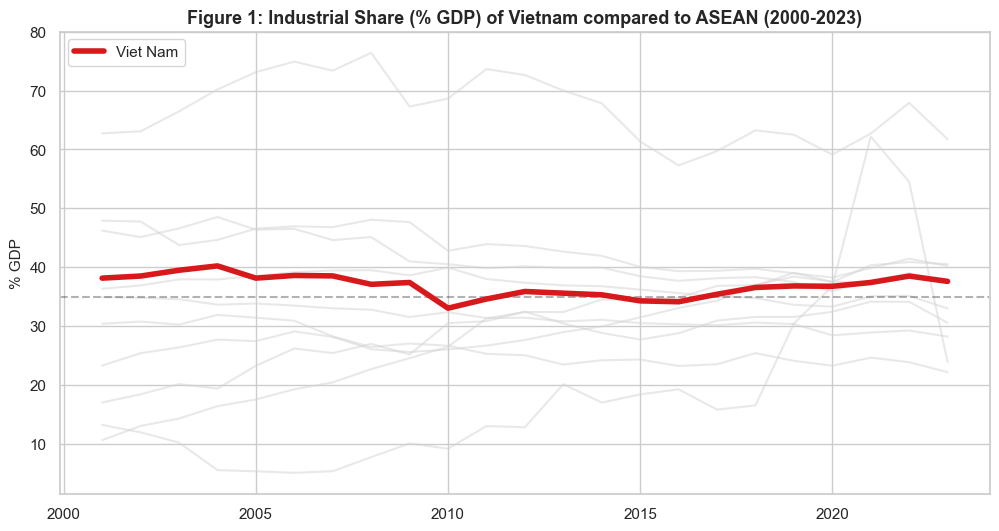

In [ ]:
plt.figure(figsize=(12, 6))
for country in asean_all:
    if country in df_final['Country Name'].unique():
        color = '#D7191C' if country == 'Viet Nam' else 'lightgrey'
        alpha = 1.0 if country == 'Viet Nam' else 0.5
        linewidth = 4 if country == 'Viet Nam' else 1.5
        zorder = 10 if country == 'Viet Nam' else 1
        subset = df_final[df_final['Country Name'] == country]
        plt.plot(subset['Year'], subset['Ind_GDP'], color=color, linewidth=linewidth, alpha=alpha, zorder=zorder, label=country if country == 'Viet Nam' else "")

plt.axhline(35, color='black', linestyle='--', alpha=0.3)
plt.title("Figure 1: Industrial Share (% GDP) of Vietnam compared to ASEAN (2000-2023)", fontweight='bold', fontsize=13)
plt.ylabel("% GDP")
plt.legend(loc='upper left')
plt.show()

#### Data Explanation:
The data shows the contribution share of the industrial sector (including manufacturing, construction, mining) to the gross domestic product (GDP). The 35% dashed line represents the threshold of a highly industrialized economy.

#### In-depth Insights:
1. **Structural Divergence:** While ASEAN-4 economies (like Thailand, Indonesia) peaked their industrialization before 2010 and are trending downwards (early deindustrialization), Vietnam is the only country maintaining a stable growth trajectory.
2. **"Factory" Position:** Consistently anchoring above the 35% GDP mark confirms Vietnam is at the **Peak Industrialization** stage. This shows Vietnam's role as an important manufacturing link in the global value chain, but simultaneously forecasts immense emission pressure analyzed in subsequent steps.

## 1.3 **Question 2:** Evaluating the Coupling between industrial output and Carbon emissions
- **Rationale for selection:** Verifying the Kuznets Curve theory. We need to know Vietnam's trajectory: Are emissions increasing positively with the economy or is there evidence of decoupling?
- **Metrics:** Combining `Ind_GDP` (% Industry) and `CO2_PC` ($CO_2$ emissions per capita - tons/person).

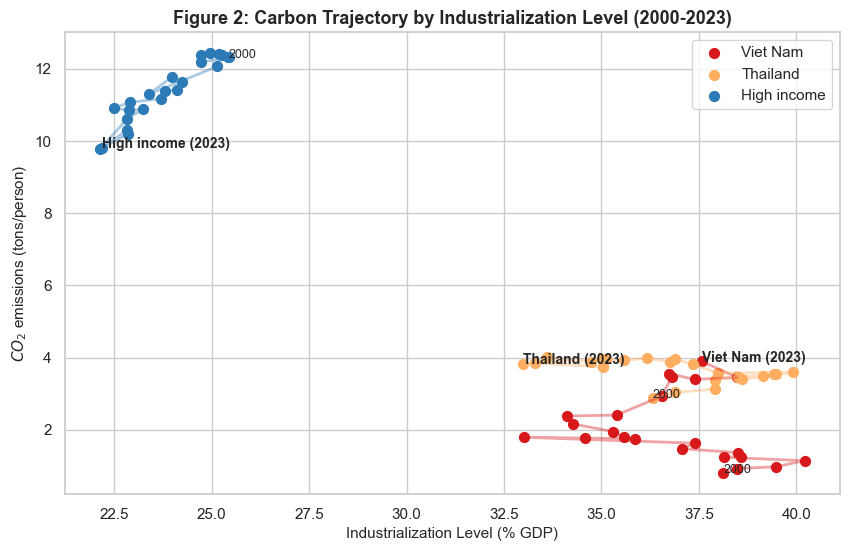

In [ ]:
plt.figure(figsize=(10, 6))
targets = ['Viet Nam', 'Thailand', 'High income']
colors = {'Viet Nam': '#D7191C', 'Thailand': '#FDAE61', 'High income': '#2C7BB6'}

for country in targets:
    subset = df_final[df_final['Country Name'] == country].dropna(subset=['Ind_GDP', 'CO2_PC']).sort_values('Year')
    plt.plot(subset['Ind_GDP'], subset['CO2_PC'], color=colors[country], alpha=0.4, linewidth=2)
    plt.scatter(subset['Ind_GDP'], subset['CO2_PC'], color=colors[country], s=50, label=country)

    plt.text(subset['Ind_GDP'].iloc[0], subset['CO2_PC'].iloc[0], '2000', fontsize=9)
    plt.text(subset['Ind_GDP'].iloc[-1], subset['CO2_PC'].iloc[-1], f"{country} (2023)", fontweight='bold', fontsize=10)

plt.title("Figure 2: Carbon Trajectory by Industrialization Level (2000-2023)", fontweight='bold', fontsize=13)
plt.xlabel("Industrialization Level (% GDP)")
plt.ylabel("$CO_2$ emissions (tons/person)")
plt.legend()
plt.show()

#### Data Explanation:
The Trajectory chart connects annual data points. The horizontal axis is industrial scale, the vertical axis is carbon emissions. The direction of the line indicates the relationship between growth and pollution.

#### In-depth Insights:
1. **Phase 1 of the Kuznets Curve:** Vietnam's trajectory is a steep upward slope to the Northeast. This affirms Vietnam is firmly in **Phase 1 (Intensive phase)** of the Kuznets curve: industrial output increases entail corresponding increases in carbon emissions.
2. **Strong Coupling:** Unlike the **High Income** group (which has reached the decoupling point - moving leftwards), Vietnam has yet to optimize clean technology in production. Each unit of industrial GDP generated still carries a larger "carbon burden" each year.

## 1.4 **Question 3:** Correlation between environmental degradation and public health resilience
- **Rationale for selection:** Deciphering the health paradox. Normally, increased air pollution reduces quality of life. The group wants to test whether Vietnam is successfully using economic benefits to offset environmental risks.
- **Metrics:** `PM25` ($PM_{2.5}$ concentration $\mu g/m^3$) and `Life_Exp` (Life expectancy at birth - years).

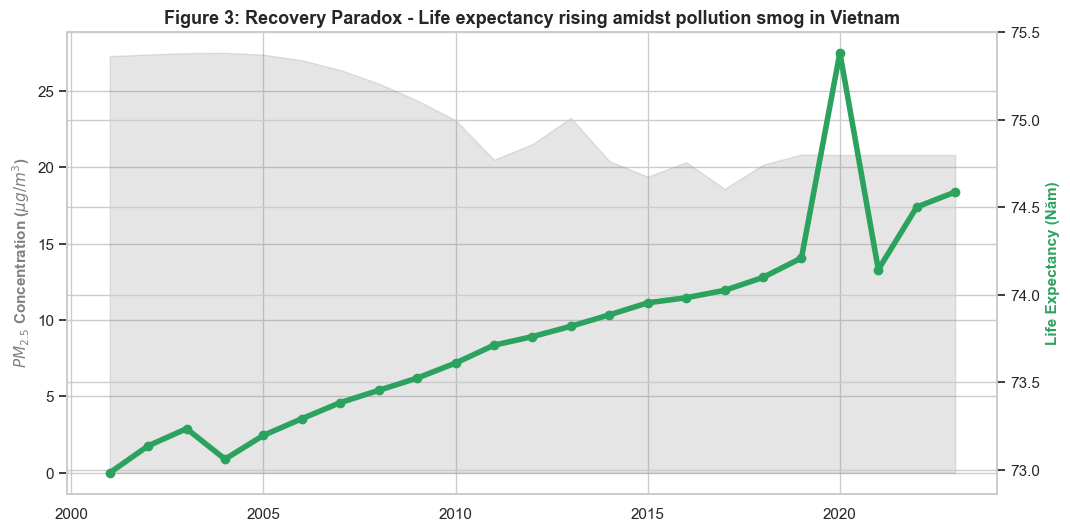

In [ ]:
df_vn = df_final[df_final['Country Name'] == 'Viet Nam'].dropna(subset=['PM25', 'Life_Exp'])
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Trục 1: Vùng sương mù ô nhiễm (Area Chart)
ax1.fill_between(df_vn['Year'], df_vn['PM25'], color='grey', alpha=0.2, label='$PM_{2.5}$ Concentration')
# Trục 2: Thành quả tuổi thọ (Line Chart)
ax2.plot(df_vn['Year'], df_vn['Life_Exp'], color='#2CA25F', linewidth=4, marker='o', markersize=6, label='Life Expectancy')

ax1.set_ylabel("$PM_{2.5}$ Concentration ($\mu g/m^3$)", color='grey', fontweight='bold')
ax2.set_ylabel("Life Expectancy (Năm)", color='#2CA25F', fontweight='bold')
plt.title("Figure 3: Recovery Paradox - Life expectancy rising amidst pollution smog in Vietnam", fontweight='bold', fontsize=13)
plt.show()

#### Data Explanation:
The chart uses Dual-axis. The gray shaded area represents $PM_{2.5}$ fine dust pressure. The blue line shows the variation in the average life expectancy of Vietnamese people over two decades.

#### In-depth Insights:
1. **Contrasting trends:** Although $PM_{2.5}$ concentration in Vietnam remains at hazardous levels (around $20 \mu g/m^3$, double the WHO safe limit), average life expectancy has steadily increased from 73 to 75 years.
2. **Fiscal Space Hypothesis:** This serves as evidence for the **"Paying with social budget"** model. Profits accumulated from industrialization (question 1) have provided financial resources for the Government to invest in preventive healthcare, vaccines, and clean water. Current medical advances are temporarily "overcoming" the negative environmental impacts, but this is a fragile equilibrium that demands attention in the future.

## 1.5 SUMMARY AND RECOMMENDATIONS
Data analysis for the 2000-2023 period shows Vietnam operating a **"High Input - High Output"** development model.
- Vietnam has the strongest industrial orientation in ASEAN, impressively improving life expectancy and basic quality of life for its people.
- However, this development is still reliant on "borrowing" environmental resources (Phase 1 EKC).
- **Recommendations:** To escape the middle-income trap sustainably like the High Income group, Vietnam must soon reach the "Turning point" by shifting towards renewable energy and gradually reducing GDP dependence on carbon-intensive industries.

# Part 2 – ASEAN Labor Market: Does Low Unemployment Mean High Job Quality?

## Motivation:
- In macroeconomic reports, Viet Nam is often recognized as having a relatively **low unemployment rate** compared to many countries in the region and globally.  
- However, an important question arises: **Does low unemployment truly reflect a “good” labor market?**  
- In reality, many studies suggest that in developing countries, low unemployment can coexist with **high levels of vulnerable employment**, as workers are forced to accept informal and unstable jobs.  
- Therefore, this project aims to address the central question:  
  **“Does Viet Nam truly have a high-quality labor market, or is low unemployment sustained by less stable and low-quality jobs?”**

---

## Analysis Objectives:

- **Question 1**: How do unemployment rates and vulnerable employment compare between Viet Nam and other ASEAN countries?  

- **Question 2**: What trends can be observed in unemployment and vulnerable employment in Viet Nam during the period 2000–2023?  

- **Question 3**: How do economic structure, level of development, and education explain the relationship with vulnerable employment, and the “low unemployment paradox”?  

---

## Key Indicators:

| Indicator Code | Description |
|----------------|-------------|
| SL.UEM.TOTL.ZS | Unemployment rate (% of total labor force) |
| SL.EMP.VULN.ZS | Vulnerable employment (% of total employment) |
| SL.EMP.MPYR.ZS | Employers (% of total employment) |
| SL.AGR.EMPL.ZS | Employment in agriculture (% of total employment) |
| NY.GDP.PCAP.CD | GDP per capita (current US$) |
| SE.ENR.TERT.FM.ZS | Tertiary school enrollment (% gross) |

---

## 2.1 Loading data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Cấu hình phong cách
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11, 'figure.facecolor': 'white'})

print("Đang tải và xử lý dữ liệu...")
df_raw = pd.read_excel('../data.xlsx', sheet_name='Data')

# Làm sạch tên cột năm
year_cols = [col for col in df_raw.columns if '[YR' in str(col)]
rename_dict = {col: int(str(col).split(' ')[0]) for col in year_cols}
df_raw.rename(columns=rename_dict, inplace=True)
df_raw.replace('..', np.nan, inplace=True)

# Melt
id_vars = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
df_melted = pd.melt(df_raw, id_vars=id_vars, value_vars=list(rename_dict.values()),
                    var_name='Year', value_name='Value')
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

# Lọc Quốc gia
target_countries = [
    'Viet Nam', 'Thailand', 'Indonesia', 'Malaysia', 'Philippines',
    'Singapore', 'Cambodia', 'Lao PDR', 'Myanmar',
]
df_clean = df_melted[df_melted['Country Name'].isin(target_countries)].copy()

# Pivot
df_multi = df_clean.pivot_table(index=['Country Name', 'Year'], columns='Series Code', values='Value').reset_index()

# Từ điển ánh xạ các Mã Series sang Tên dễ gọi
indicators = {
    'SL.UEM.TOTL.ZS': 'Unemp_Total',       # Thất nghiệp
    'SL.EMP.VULN.ZS': 'Vuln_Emp',          # Lao động dễ tổn thương
    'NY.GDP.PCAP.CD': 'GDP_pc',            # GDP per capita
    'SL.EMP.MPYR.ZS': 'Employers',         # Employers
    'SL.AGR.EMPL.ZS': 'Agri_Emp',
    'SE.TER.ENRR': 'Education'           
}

df_multi.rename(columns=indicators, inplace=True)
print(f"Xử lý thành công! Kích thước ma trận: {df_multi.shape}")

Đang tải và xử lý dữ liệu...
Xử lý thành công! Kích thước ma trận: (207, 46)


## 2.2 **Question 1**: How do unemployment rates and vulnerable employment compare between Viet Nam and other ASEAN countries?  


In [ ]:
print("\n--- Phân tích Mục tiêu 1: Thất nghiệp vs Lao động dễ tổn thương ---")

# Chọn quốc gia ASEAN (không lấy income group cho biểu đồ này)
asean_countries = [
    'Viet Nam', 'Thailand', 'Indonesia', 'Malaysia',
    'Philippines', 'Singapore', 'Cambodia', 'Lao PDR', 'Myanmar'
]

df_asean = df_multi[df_multi['Country Name'].isin(asean_countries)].copy()

# Lọc giai đoạn gần đây
df_recent = df_asean[df_asean['Year'] >= 2020].copy()

# Lấy trung bình để giảm nhiễu
df_plot = df_recent.groupby('Country Name')[['Unemp_Total', 'Vuln_Emp']].mean().reset_index()

print(df_plot.head())


--- Phân tích Mục tiêu 1: Thất nghiệp vs Lao động dễ tổn thương ---
Series Code Country Name  Unemp_Total   Vuln_Emp
0               Cambodia      0.26725  53.257256
1              Indonesia      3.71300  50.292278
2                Lao PDR      1.70600  77.309576
3               Malaysia      4.24200  22.324826
4                Myanmar      2.96400  62.847897


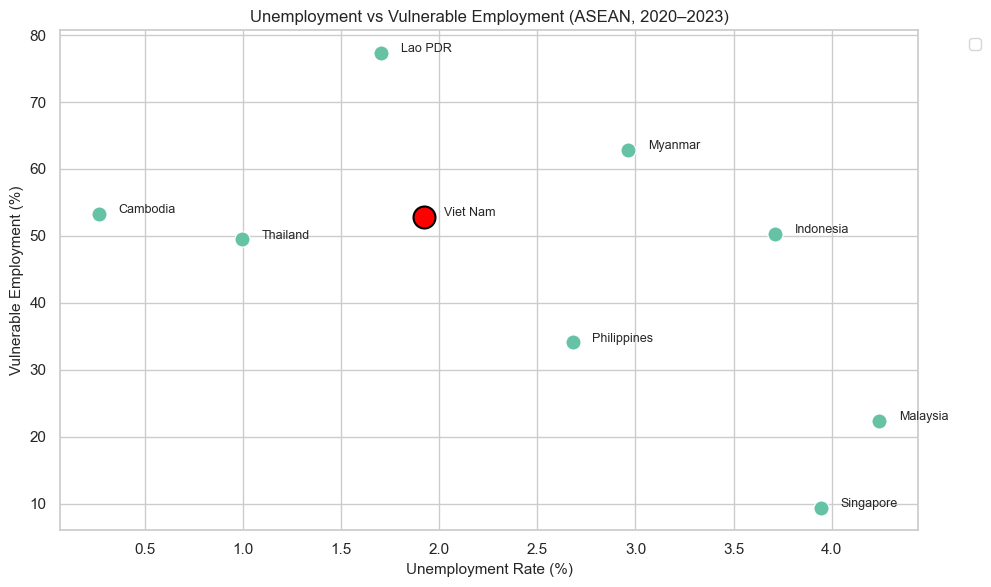

In [ ]:
plt.figure(figsize=(10, 6))

df_plot['Highlight'] = df_plot['Country Name'].apply(
    lambda x: 'Viet Nam' if x == 'Viet Nam' else 'Other'
)
sns.scatterplot(
    data=df_plot,
    x='Unemp_Total',
    y='Vuln_Emp',
    s=120
)

# Highlight Việt Nam
vn = df_plot[df_plot['Country Name'] == 'Viet Nam']
plt.scatter(
    vn['Unemp_Total'], vn['Vuln_Emp'],
    s=250, edgecolor='black',color='red',linewidth=1.5
)

# Annotate tên nước
for i in range(len(df_plot)):
    plt.text(
        df_plot['Unemp_Total'][i] + 0.1,
        df_plot['Vuln_Emp'][i] + 0.1,
        df_plot['Country Name'][i],
        fontsize=9
    )

plt.title("Unemployment vs Vulnerable Employment (ASEAN, 2020–2023)")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Vulnerable Employment (%)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Observations
- Vietnam has a low unemployment rate of around 1.8%, but a very high vulnerable employment rate of up to 52%.
- Singapore has a higher unemployment rate than Vietnam, but an extremely low vulnerable employment rate of only 9%.
- Additionally, Cambodia and Laos show a similar pattern to Vietnam, with low unemployment rates but very high vulnerable employment.

--> This indicates that there is no inverse relationship between unemployment and job quality.

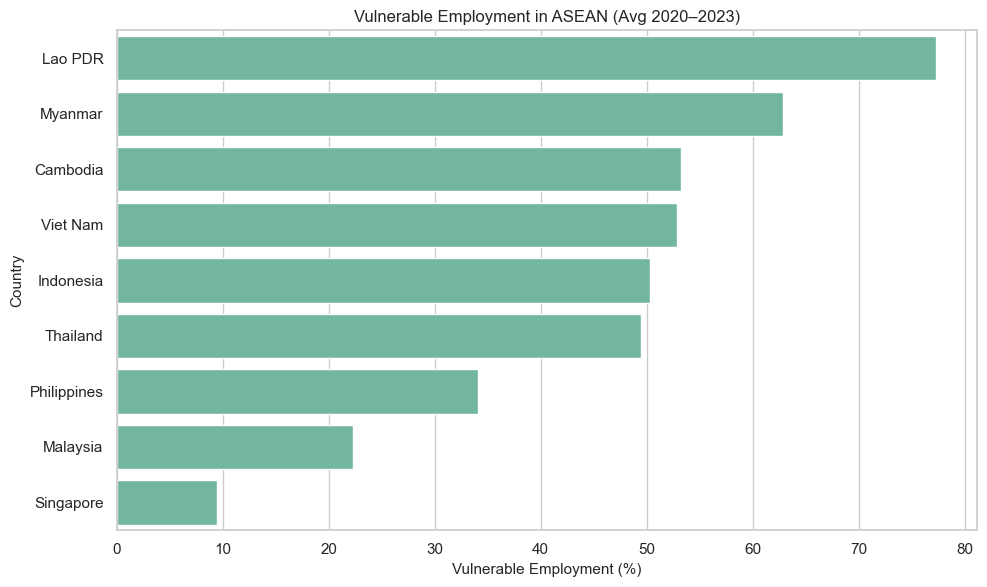

In [ ]:
plt.figure(figsize=(10, 6))

df_sorted = df_plot.sort_values(by='Vuln_Emp', ascending=False)

sns.barplot(
    data=df_sorted,
    x='Vuln_Emp',
    y='Country Name'
)

plt.title("Vulnerable Employment in ASEAN (Avg 2020–2023)")
plt.xlabel("Vulnerable Employment (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Observations
- Vietnam has a vulnerable employment rate of around 52%, higher than Indonesia, the Philippines, Malaysia, and Singapore, but lower than Laos, Myanmar, and Cambodia, indicating that Vietnam belongs to the medium–high group in terms of vulnerable employment within ASEAN.

### Conclusion
- The analysis results show that Vietnam has a lower unemployment rate compared to other ASEAN countries; however, the rate of vulnerable employment remains high. This reflects a paradox in the labor market: low unemployment does not necessarily imply high job quality.  
- Compared to more developed countries such as Singapore and Malaysia, Vietnam has a significantly higher rate of vulnerable employment, indicating that a large proportion of workers are still engaged in the informal sector or unstable jobs.  
- Meanwhile, less developed countries such as Laos and Myanmar exhibit similar characteristics but at a more severe level, suggesting a relationship between the level of economic development and job quality.  
- Therefore, it can be concluded that although Vietnam’s labor market is effective in job creation (low unemployment), the quality of employment is still limited, highlighting the need to improve the economic structure and enhance labor quality.  
- These findings raise questions about the causes of the high rate of vulnerable employment, which will be further analyzed in Objective 3 through factors such as economic structure and level of development.

## 2.3 **Question 2**: What trends can be observed in unemployment and vulnerable employment in Viet Nam during the period 2000–2023?  


In [ ]:
print("\n--- Mục tiêu 2: Xu hướng Việt Nam (2000–2023) ---")

df_vn = df_multi[df_multi['Country Name'] == 'Viet Nam'].copy()

# Lọc giai đoạn
df_vn = df_vn[(df_vn['Year'] >= 2000) & (df_vn['Year'] <= 2023)]

# Sắp xếp theo năm
df_vn = df_vn.sort_values(by='Year')

print(df_vn[['Year', 'Unemp_Total', 'Vuln_Emp']].head())


--- Mục tiêu 2: Xu hướng Việt Nam (2000–2023) ---
Series Code  Year  Unemp_Total   Vuln_Emp
184          2001        2.760  71.178274
185          2002        2.120  71.568136
186          2003        2.250  70.114415
187          2004        2.140  66.366174
188          2005        2.078  65.828571


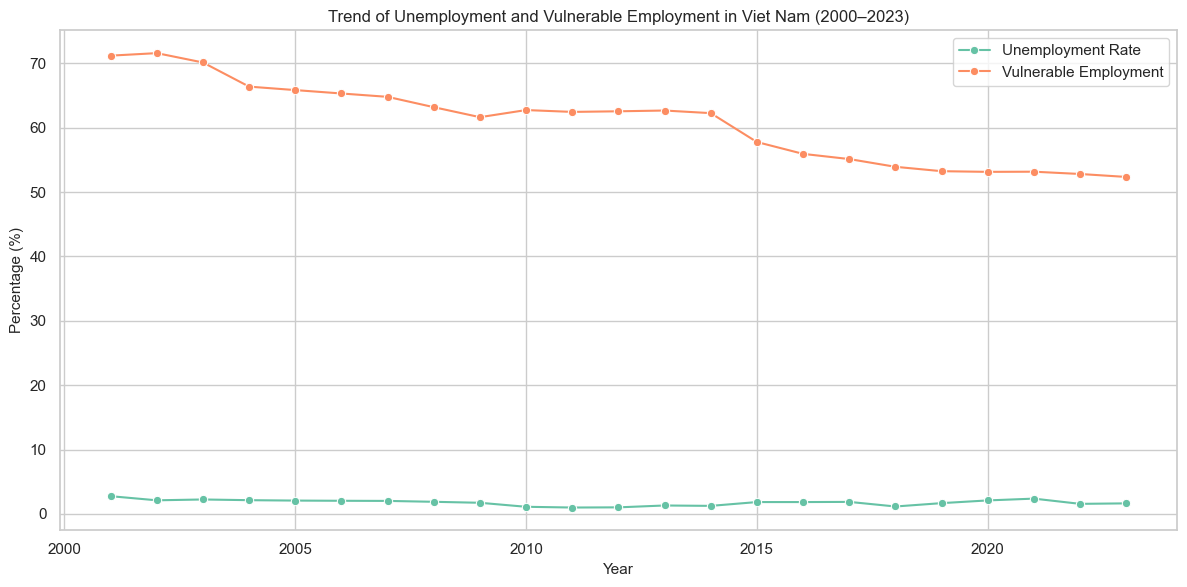

In [ ]:
plt.figure(figsize=(12, 6))

# Line Unemployment
sns.lineplot(
    data=df_vn,
    x='Year',
    y='Unemp_Total',
    label='Unemployment Rate',
    marker='o'
)

# Line Vulnerable
sns.lineplot(
    data=df_vn,
    x='Year',
    y='Vuln_Emp',
    label='Vulnerable Employment',
    marker='o'
)

plt.title("Trend of Unemployment and Vulnerable Employment in Viet Nam (2000–2023)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")


plt.legend()
plt.tight_layout()
plt.show()

#### Observations
- Vulnerable employment decreased significantly from 73–74% in 2000 to around 58–59% in 2023, showing a clear and continuous downward trend with no major fluctuations.
- The unemployment rate has consistently remained at around 1.5–2.5%, indicating long-term stability.
- However, the gap between the two indicators remains very large, suggesting that Vietnam maintains low unemployment while vulnerable employment is still high.

### Conclusion
- The analysis shows that the rate of vulnerable employment in Vietnam declined substantially during the 2000–2023 period, from over 70% to around 60%, reflecting clear improvements in job quality and structural economic transformation.
- However, the unemployment rate over the same period has remained low and stable, fluctuating around 1.5–2.5%, indicating that the labor market is effective at absorbing workers but does not fully reflect job quality.
- The coexistence of low unemployment and high vulnerable employment suggests that Vietnam’s labor market still faces significant limitations, particularly due to the large share of workers in the informal sector.
- Therefore, despite improvements over time, job quality in Vietnam has not yet reached a high level and requires further analysis through factors such as economic structure and level of development in Objective 3.

## 2.4 **Question 3**: How do economic structure, level of development, and education explain the relationship with vulnerable employment, and the “low unemployment paradox”?  


### 2.4.1 Agriculture vs Vulnerable Employment

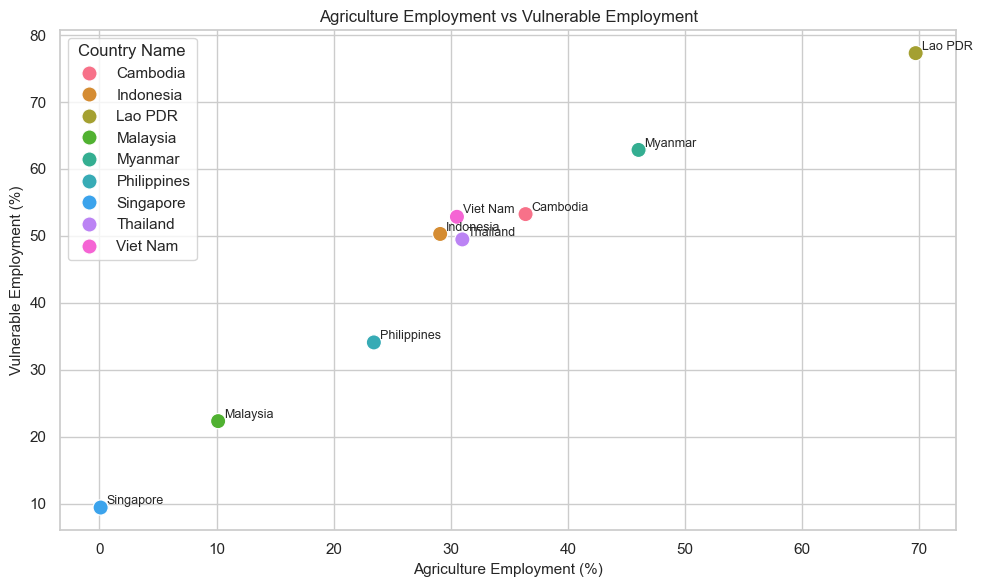

In [ ]:
df_agri = df_multi[df_multi['Year'] >= 2020].groupby('Country Name')[
    ['Agri_Emp', 'Vuln_Emp']
].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_agri,
    x='Agri_Emp',
    y='Vuln_Emp',
    hue='Country Name',
    s=120
)

# Label
for i in range(len(df_agri)):
    plt.text(
        df_agri['Agri_Emp'][i] + 0.5,
        df_agri['Vuln_Emp'][i] + 0.5,
        df_agri['Country Name'][i],
        fontsize=9
    )

plt.title("Agriculture Employment vs Vulnerable Employment")
plt.xlabel("Agriculture Employment (%)")
plt.ylabel("Vulnerable Employment (%)")

plt.tight_layout()
plt.show()

### Observations:
- The chart shows a fairly clear positive relationship between the share of employment in agriculture and the rate of vulnerable employment: countries with a higher proportion of agricultural workers tend to have higher vulnerable employment rates. For example, Singapore has almost no agricultural labor and only about 9% vulnerable employment, whereas Laos has around 70% agricultural employment and nearly 80% vulnerable employment.

--> This indicates that economic structure is a strong explanatory factor for job quality.

### 2.4.2 GDP vs Vulnerable

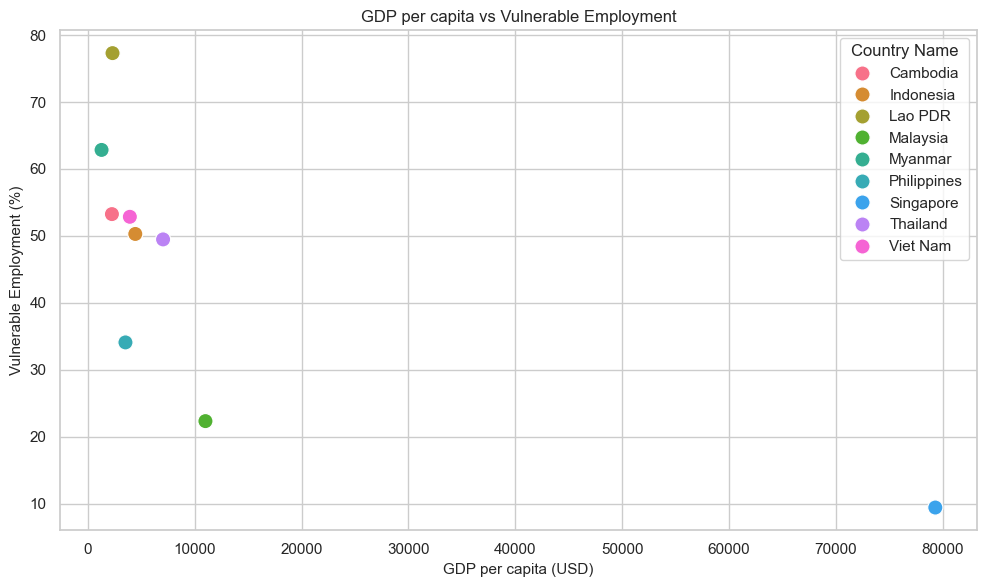

In [ ]:
df_gdp = df_multi[df_multi['Year'] >= 2020].groupby('Country Name')[
    ['GDP_pc', 'Vuln_Emp']
].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_gdp,
    x='GDP_pc',
    y='Vuln_Emp',
    hue='Country Name',
    s=120
)



plt.title("GDP per capita vs Vulnerable Employment")
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Vulnerable Employment (%)")

plt.tight_layout()
plt.show()

### Observations:
- The GDP per capita and vulnerable employment chart shows a fairly clear inverse relationship: countries with higher GDP per capita tend to have lower rates of vulnerable employment. Singapore and Malaysia are typical examples with high income levels and low vulnerable employment, while Lao PDR, Myanmar, Cambodia, and Vietnam have lower income levels and significantly higher vulnerable employment rates. This result suggests that the level of economic development is an important factor in explaining job quality. However, differences across some countries also indicate that GDP is not the only factor; economic structure, education level, and the degree of labor market formalization also play important roles.

### 2.4.3 Employers vs Vulnerable Employment

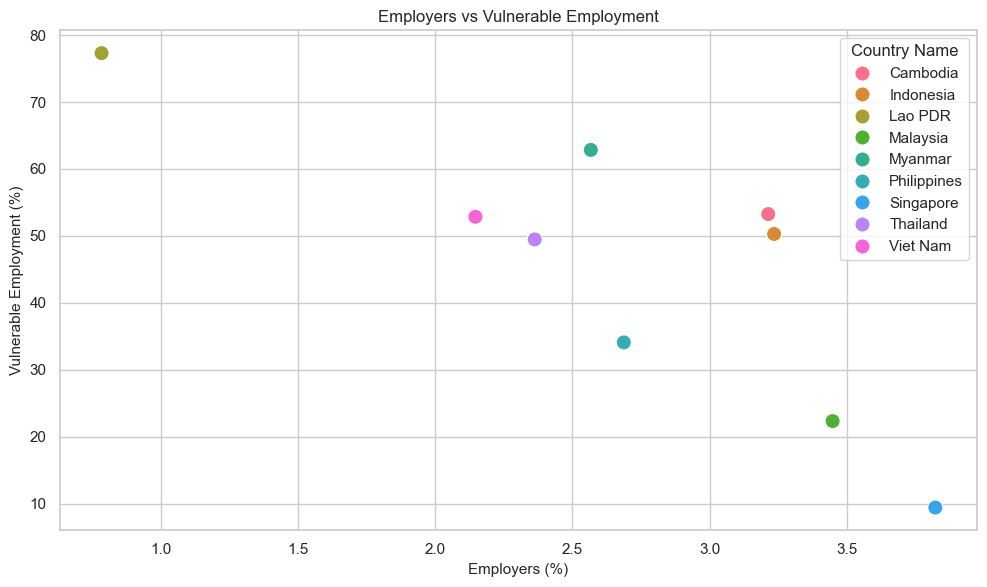

In [ ]:
df_emp = df_multi[df_multi['Year'] >= 2020].groupby('Country Name')[
    ['Employers', 'Vuln_Emp']
].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_emp,
    x='Employers',
    y='Vuln_Emp',
    hue='Country Name',
    s=120
)



plt.title("Employers vs Vulnerable Employment")
plt.xlabel("Employers (%)")
plt.ylabel("Vulnerable Employment (%)")

plt.tight_layout()
plt.show()

### Observations:
- The Employers vs. Vulnerable Employment chart shows that the relationship between the share of employers and vulnerable employment is less clear and weaker compared to the previous two charts on agricultural employment and GDP per capita. However, when considered in a broader context, this chart adds an important dimension regarding labor market structure. More developed countries such as Singapore and Malaysia not only have low vulnerable employment but also more developed enterprise sectors, whereas less developed and agriculture-dependent countries such as Lao PDR and Myanmar still exhibit very high vulnerable employment rates. This suggests that not only the number of employers matters, but also the quality of the enterprise sector, the level of formalization, and labor productivity are key determining factors. These findings are consistent with the previous two charts and further reinforce the argument that economic structure and level of development are the main factors explaining vulnerable employment as well as the “low unemployment paradox.” In addition, education is another factor that will be analyzed further in the next section.

### 2.4.4 Education vs Vulnerable Employment

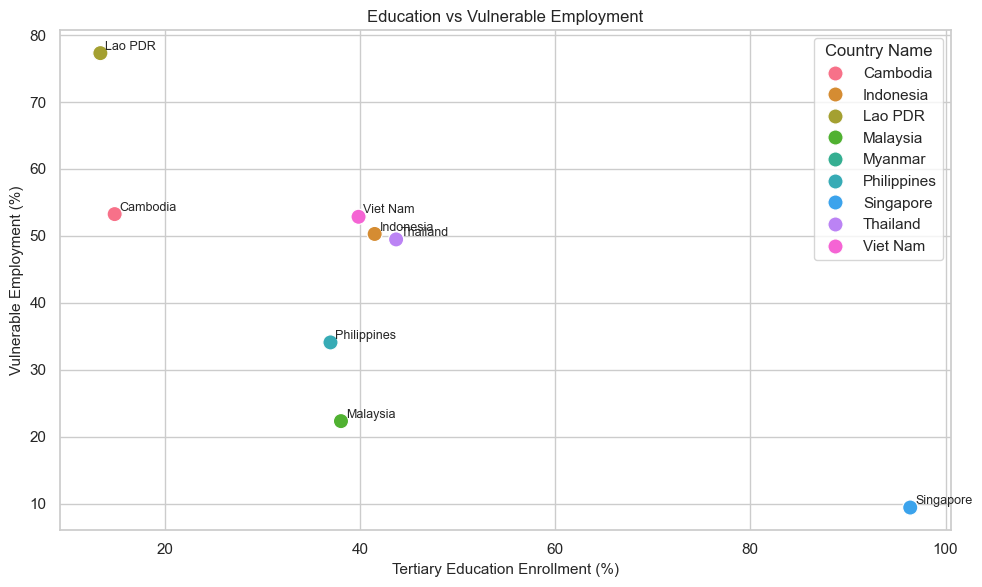

In [ ]:
df_edu = df_multi[df_multi['Year'] >= 2020].groupby('Country Name')[
    ['Education', 'Vuln_Emp']
].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_edu,
    x='Education',
    y='Vuln_Emp',
    hue='Country Name',
    s=120
)


# Label
for i in range(len(df_edu)):
    plt.text(
        df_edu['Education'][i] + 0.5,
        df_edu['Vuln_Emp'][i] + 0.5,
        df_edu['Country Name'][i],
        fontsize=9
    )

plt.title("Education vs Vulnerable Employment")
plt.xlabel("Tertiary Education Enrollment (%)")
plt.ylabel("Vulnerable Employment (%)")

plt.tight_layout()
plt.show()

### Observations:
- The Education vs. Vulnerable Employment chart shows a fairly clear inverse relationship between education level and the rate of vulnerable employment. Countries with higher tertiary education enrollment rates, such as Singapore and Malaysia, tend to have significantly lower vulnerable employment, while countries with lower education levels, such as Lao PDR and Cambodia, exhibit very high vulnerable employment rates. When linked with the previous three charts, education can be seen as a mediating mechanism connecting economic development, employment structure, and labor quality. Higher education enables workers to move out of low-productivity agriculture, enter the formal enterprise sector, and access more stable jobs. However, education is not the only factor; its effectiveness also depends on the level of economic development and the capacity to generate high-quality jobs. These findings further reinforce the argument that explaining vulnerable employment and the “low unemployment paradox” requires considering economic structure, level of development, labor market structure, and education simultaneously.

### 2.4.5 Heatmap

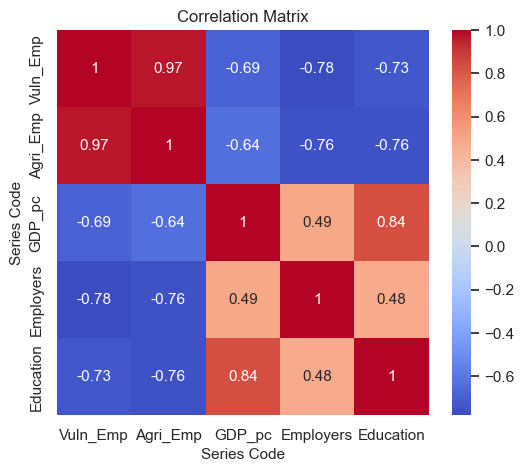

In [ ]:
corr = df_multi[['Vuln_Emp', 'Agri_Emp', 'GDP_pc', 'Employers','Education']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

### Conclusion
- The correlation matrix strongly reinforces the observations from the previous charts. Vulnerable employment shows a very strong positive correlation with the share of agricultural employment (0.97), and significant negative correlations with GDP per capita (-0.69), education (-0.73), and the share of employers (-0.78). This indicates that vulnerable employment mainly occurs in economies that are still dependent on agriculture, have lower levels of development, limited education, and underdeveloped enterprise sectors. In addition, the explanatory variables are also closely related to each other, particularly GDP per capita and education (0.84), suggesting that economic development, education, and structural transformation jointly contribute to better job quality. Therefore, it can be concluded that to properly understand the labor market, it is not sufficient to look only at the unemployment rate; vulnerable employment must also be considered to identify the “low unemployment paradox,” where unemployment is low but jobs remain unstable, informal, and low in productivity.

# Part 3 – Gender Equality in ASEAN: Where Is the Gap Between Men and Women?


## Motivation

- Our team chose this topic because of recent debates, campaigns, and social movements about feminism and women’s rights.

- From that context, when we had the chance to access and analyse the data in Lab 2, we raised a key question: **“Does gender inequality still exist in the labour market between men and women?”**

- However, this is a broad question and is affected by many factors that statistics cannot fully capture. Therefore, we narrow it down to: **“Are women being fairly valued in the labour market?”**


## Analytical Objectives

1. **Question 1**: How do women participate in the labour market in Viet Nam and in other ASEAN countries? Is there a large gap compared with men, and are there any notable trends over 2000–2023?


2. **Question 2**: What role does education play for both genders? Is there a noticeable difference in educational attainment between men and women?


3. **Question 3**: What do job quality and promotion opportunities for women in ASEAN tell us about gender inequality? Are women “trapped” in vulnerable positions, or do they have real chances to move up in the economy?

## 3.1 Import libraries and load data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Data file path (same folder as this notebook)

data_path = "../data.xlsx"

# Read the main WDI file after filtering indicators
# Missing values in WDI are usually coded as "..", so we set na_values
df = pd.read_excel(data_path, sheet_name='Data')
print("Data shape (rows, columns):", df.shape)
df.head()

Data shape (rows, columns): (621, 27)


,Country Name,Country Code,Series Name,Series Code,2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Viet Nam,VNM,GDP per person employed (constant 2021 PPP $),SL.GDP.PCAP.EM.KD,9045.552745,9417.31083,9924.842514,10469.636383,10992.795861,11423.147758,11834.836051,12070.634754,12348.62911,12790.154973,13356.966644,13901.08548,14358.54606,15079.651466,16009.808688,17000.21478,17973.379557,18936.439476,20457.730421,21529.549992,22082.432017,23275.247865,24513.220365
1,Viet Nam,VNM,"Industry (including construction), value added...",NV.IND.TOTL.ZS,38.129422,38.486679,39.470008,40.20875,38.13114,38.584731,38.511625,37.077696,37.388186,33.022877,34.580409,35.860232,35.57515,35.298568,34.266547,34.115229,35.390364,36.542433,36.803137,36.743713,37.391519,38.482361,37.58157
2,Viet Nam,VNM,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,3.977335,3.992687,3.666012,3.544081,3.390404,3.616001,8.654718,9.663039,7.16882,5.434739,4.304874,4.278323,4.164545,3.940862,4.931908,4.900893,5.011487,4.998283,4.821075,4.558362,4.273146,4.329473,4.264071
3,Viet Nam,VNM,"Personal remittances, received (% of GDP)",BX.TRF.PWKR.DT.GD.ZS,3.365438,5.047897,5.309397,5.084986,5.465594,5.725335,7.983008,6.863693,5.676573,5.141943,4.824009,4.045183,4.412078,4.195304,3.364855,3.327976,3.342984,3.286407,3.255489,3.091196,3.471478,3.192684,3.226865
4,Viet Nam,VNM,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,71.493,70.833,70.353,70.098,70.381,70.727,71.138,71.55,71.906,71.731,71.715,71.983,72.906,73.059,72.863,72.53,72.575,72.897,71.511,69.095,69.107,69.878,69.215


## 3.2 Quick overview of the dataset

In this part, we take a quick look at the data structure:

- Identifier columns: `Country Name`, `Country Code`, `Series Name`, `Series Code`.

- Year columns: from around 2000 to 2023, in the form `2000 [YR2000]`, ... storing indicator values by year.


Steps:

1. Count the number of records and the number of different indicators (Series) in the dataset.

2. Check for missing values (NA).

*General information about the dataframe*

In [ ]:
print("\nData columns:")
print(df.columns.tolist())

print("\nNumber of countries in the dataset:", df["Country Name"].nunique())
print("Number of different series (indicators):", df["Series Code"].nunique())


Data columns:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]']

Number of countries in the dataset: 16
Number of different series (indicators): 44


*Missing values ratio by column*

In [ ]:
year_cols = [c for c in df.columns if "[YR" in c]
print("\nNumber of year columns:", len(year_cols))

missing_ratio = df[year_cols].isna().mean().sort_values(ascending=False)
print("\nAverage missing ratio in year columns (top 10):")
print(missing_ratio.head(10))


Number of year columns: 23

Average missing ratio in year columns (top 10):
2001 [YR2001]    0.008052
2002 [YR2002]    0.008052
2003 [YR2003]    0.008052
2004 [YR2004]    0.008052
2005 [YR2005]    0.008052
2006 [YR2006]    0.008052
2007 [YR2007]    0.008052
2008 [YR2008]    0.008052
2009 [YR2009]    0.008052
2010 [YR2010]    0.008052
dtype: float64


## 3.3 Preprocessing
##### **Convert data to long format**

In the original form, each year is a separate column. To visualise and analyse time trends more easily, we convert to **long format** with the main columns:

- `Country Name`, `Country Code`
- `Series Name`, `Series Code`
- `Year` (year)
- `Value` (indicator value)

*Convert to long format*

In [ ]:
# drop rows where all year columns are NaN
df = df.dropna(subset=year_cols, how="all").reset_index(drop=True)

id_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]

df_long = df.melt(id_vars=id_cols,
                  value_vars=year_cols,
                  var_name="Year",
                  value_name="Value")

print("df_long" in globals())

*Extract year from string*
###### Example: "2000 [YR2000]" -> 2000

In [ ]:
df_long["Year"] = pd.to_numeric(
    df_long["Year"].str.extract(r"(\d{4})", expand=False),
    errors="coerce"
 )
df_long = df_long.dropna(subset=["Year"]).copy()
df_long["Year"] = df_long["Year"].astype(int)

#format value to numeric, coerce errors to NaN
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")

*Filter ASEAN countries*

In [ ]:
asean_countries = ["Viet Nam", "Singapore", "Malaysia", "Thailand", "Indonesia", "Philippines", "Brunei Darussalam", "Cambodia", "Lao PDR", "Myanmar", "Timor-Leste"]
df_asean = df_long[df_long["Country Name"].isin(asean_countries)].copy()

print("Long-format data size (ASEAN):", df_asean.shape)
df_asean.head()

NameError: name 'df_long' is not defined

In [ ]:
print("\nData columns:")
print(df_asean.columns.tolist())

print("\nNumber of countries in the dataset:", df_asean["Country Name"].nunique())
print("Number of different series (indicators):", df_asean["Series Code"].nunique())


Data columns:


NameError: name 'df_asean' is not defined

## 3.4 **Question 1** How do women participate in the labour market in Viet Nam and other ASEAN countries? Is there a large gap compared with men, or any notable trend over 2000–2023?

Indicators used:

- `SL.TLF.CACT.FE.ZS`: Labor force participation rate, female (% of female population ages 15+).

- `SL.TLF.CACT.MA.ZS`: Labor force participation rate, male (% of male population ages 15+).

Motivation:
- The idea that “men build the house, women build the home” has existed for a long time in Asian societies, especially in Southeast Asia. This mindset partly comes from culture and customs, and is also influenced by Confucianism over many generations.
- In the context of modernisation and reform (2000–2023), we want to check whether this mindset still exists, and if yes, to what extent. The first step is to analyse indicators related to labour market participation.
- Being able to participate in the labour market means having financial independence, being able to support oneself and contribute financially to the family. This is an important aspect when assessing gender equality.

Objectives:

- Analyse how the female labour force participation rate changes over time for each country.
- Measure the gap between men and women in labour force participation at the most recent time point in the data (year 2023), and compare across countries.

Further questions:
- How much does population size affect the observed patterns?
- Do we need to look more deeply at male participation trends to have a more complete picture of the gender gap?

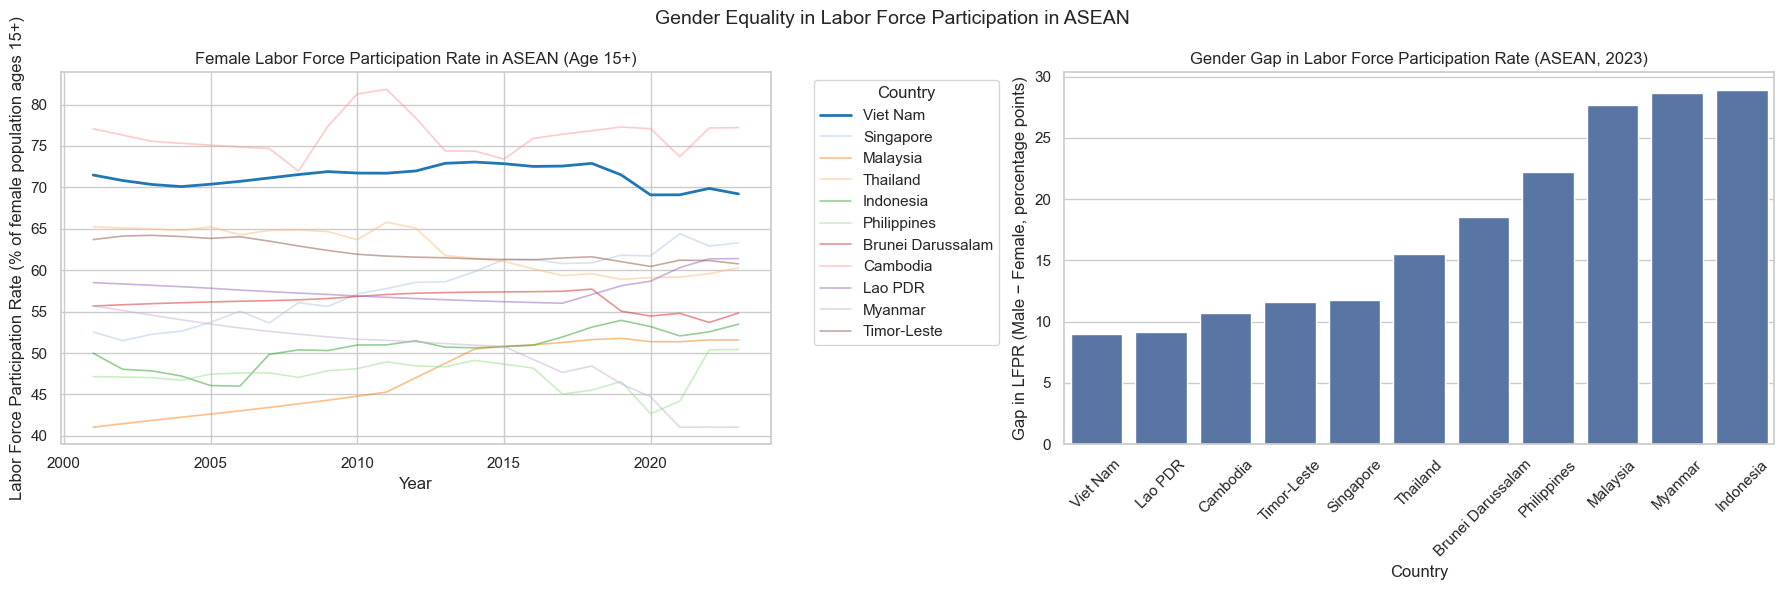

In [ ]:
question1_section3 = {
    "female": "SL.TLF.CACT.FE.ZS",
    "male": "SL.TLF.CACT.MA.ZS",
}

df_q1_sect3 = df_asean[df_asean["Series Code"].isin(question1_section3.values())].copy()

lfpr_pivot = df_q1_sect3.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Code",
    values="Value"
 )

lfpr_pivot = lfpr_pivot.rename(columns={
    question1_section3["female"]: "lfpr_female",
    question1_section3["male"]: "lfpr_male",
}).reset_index()

lfpr_pivot["gap_male_minus_female"] = lfpr_pivot["lfpr_male"] - lfpr_pivot["lfpr_female"]

# Choose reference year for comparison

year_ref_lfpr = 2023
if year_ref_lfpr not in lfpr_pivot["Year"].unique():
    year_ref_lfpr = int(lfpr_pivot["Year"].max())

latest_lfpr = lfpr_pivot[lfpr_pivot["Year"] == year_ref_lfpr].dropna(subset=["lfpr_female", "lfpr_male"])
latest_lfpr = latest_lfpr.sort_values("gap_male_minus_female")

# Line chart of female LFPR over time for each country
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# =======================
# (1) Line chart: Female LFPR over time (ASEAN)
# =======================
palette = sns.color_palette("tab20", n_colors=len(asean_countries))

for i, country in enumerate(asean_countries):
    subset = lfpr_pivot[lfpr_pivot["Country Name"] == country]
    if subset.empty:
        continue
# color="lightgray"
    if country == 'Viet Nam':
        axes[0].plot(
            subset["Year"], subset["lfpr_female"],
            label=country, color=palette[i], linewidth=2
        )
    else:
        axes[0].plot(
            subset["Year"], subset["lfpr_female"],
            label=country, linewidth=1.2, color=palette[i], alpha=0.5
        )

axes[0].set_title("Female Labor Force Participation Rate in ASEAN (Age 15+)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Labor Force Participation Rate (% of female population ages 15+)")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Country")


# =======================
# (2) Bar chart: gender gap
# =======================
sns.barplot(
    data=latest_lfpr,
    x="Country Name",
    y="gap_male_minus_female",
    ax=axes[1]
)

axes[1].set_title(
    f"Gender Gap in Labor Force Participation Rate (ASEAN, {year_ref_lfpr})"
 )
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Gap in LFPR (Male − Female, percentage points)")
axes[1].tick_params(axis='x', rotation=45)

axes[1].axhline(0, color="black", linewidth=0.8)
fig.suptitle(
    "Gender Equality in Labor Force Participation in ASEAN",
    fontsize=14
)

# =======================
# General layout
# =======================
plt.tight_layout()
plt.show()

### Insights and Conclusion for Question 1

**Reasons for choosing the charts:**

- The line chart shows how female labour force participation (LFPR) changes over time (2000–2023), helping compare Viet Nam with other ASEAN countries in terms of trend and stability.
- The bar chart (male − female LFPR in 2023) provides a snapshot of the participation gap at the most recent time point, making cross-country comparison clearer.

**Main insights:**

- Viet Nam consistently belongs to the group of countries with high female LFPR, staying around ~70% over most of the period. Compared to ASEAN, it is higher than many countries and only lower Cambodia.
- The trend for Viet Nam is relatively stable over time, with only a slight decline in some periods. In contrast, several ASEAN countries show more noticeable upward or downward changes.
- In 2023, most ASEAN countries have higher male participation than female, but the gap in Viet Nam is relatively small to moderate compared to the regional range.
- Some countries show a much larger gap, indicating that the distance between male and female participation rates varies significantly across ASEAN.

**Conclusion:**

- Compared to ASEAN, Viet Nam stands out with consistently high female participation and a relatively moderate gap with male participation.
- These patterns suggest that women in Viet Nam are actively present in the labour market relative to many countries in the region.
- This can be considered one of the factors that may relate to gender differences in the labour market, but it is not sufficient on its own to draw conclusions, and should be analysed together with other indicators.

## 3.5 **Question 2** What role does education play for both genders? Is there a gap in educational attainment between men and women?

Indicators used:

- `SE.TER.ENRR.FE`: School enrollment, tertiary, female (% gross).
- `SE.TER.ENRR.MA`: School enrollment, tertiary, male (% gross).

Motivation:
- After analysing the participation of men and women in the labour market, the next step is to look at the background factors that may affect this participation, in which education is very important.
- The labour market is stratified and usually linked to education levels, so we need to see where women stand in the education system in ASEAN countries.
- From there, we ask whether educational attainment is becoming a barrier for women to join the labour market.

Objectives: (around the recent years)
- Analyse the completion and enrolment rates at higher levels of education for men and women over time.
- Track the trend in tertiary enrolment for both genders to evaluate the degree of gender imbalance.

In [ ]:
question2_section3 = {
    "female": "SE.TER.ENRR.FE",
    "male": "SE.TER.ENRR.MA",
}

# Create dataframe
df_q2_sect3 = df_asean[df_asean["Series Code"].isin(question2_section3.values())].copy()

ter_pivot = df_q2_sect3.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Code",
    values="Value"
 )

ter_pivot = ter_pivot.rename(columns={
    question2_section3["female"]: "ter_female",
    question2_section3["male"]: "ter_male",
}).reset_index()

# Use the most recent year with available data

ter_pivot["female_to_male"] = ter_pivot["ter_female"] / ter_pivot["ter_male"]

# Most recent year with tertiary data
# latest_year_ter = int(ter_pivot["Year"].max())
latest_year_ter = 2023

latest_ter = ter_pivot[ter_pivot["Year"] == latest_year_ter].dropna(subset=["ter_female", "ter_male"])
latest_ter.sort_values("female_to_male", ascending=False, inplace=True)


# Bar chart of female/male parity by country for 2023
# Create figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# =======================
# (1) Bar chart: parity in 2023
# =======================
sns.barplot(
    data=latest_ter,
    x="Country Name",
    y="female_to_male",
    ax=axes[0]
)

axes[0].set_title(f"Gender Parity in Tertiary Enrollment (ASEAN, {latest_year_ter})")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Female-to-Male Gross Enrollment Ratio")
axes[0].axhline(1, color="red", linestyle="--", label="Parity (Female = Male)")
axes[0].legend()


# =======================
# (2) Line chart: Viet Nam over time
# =======================
vn_ter = ter_pivot[
    ter_pivot["Country Name"] == "Viet Nam"
].dropna(subset=["ter_female", "ter_male"])

sns.lineplot(data=vn_ter, x="Year", y="ter_female", label="Female", ax=axes[1])
sns.lineplot(data=vn_ter, x="Year", y="ter_male", label="Male", ax=axes[1])

axes[1].set_title("Tertiary Gross Enrollment Rate in Viet Nam (by Gender)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Gross Enrollment Rate (%)")
axes[1].legend(title="Gender")


# =======================
# (3) Line chart: ASEAN female/male ratio over time
# =======================
for i, country in enumerate(asean_countries):
    subset = ter_pivot[
        ter_pivot["Country Name"] == country
    ].dropna(subset=["female_to_male"])
    
    if subset.empty:
        continue
    
    if country == 'Viet Nam':
        axes[2].plot(
            subset["Year"], subset["female_to_male"],
            label=country, color=palette[i], linewidth=2
        )
    else:
        axes[2].plot(
            subset["Year"], subset["female_to_male"], label=country,
            color=palette[i], linewidth=1.2, alpha=0.3
        )

axes[2].axhline(1, color="red", linestyle="--", linewidth=1, label="Parity = 1")
axes[2].set_title("Gender Parity in Tertiary Enrollment across ASEAN")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Female-to-Male Gross Enrollment Ratio")
axes[2].legend(title="Country")

# =======================
# General layout
# =======================
fig.suptitle(
    "Gender Equality in Tertiary Education in ASEAN (Gross Enrollment Analysis)",
    fontsize=14
)
plt.tight_layout()
plt.show()

TypeError: agg function failed [how->mean,dtype->object]

### Insights and conclusion for Question 2

**Reasons for choosing the charts:**

- The bar chart of female_to_male in the most recent year allows quick comparison of female enrolment relative to male enrolment across ASEAN.
- The line chart for Viet Nam over time shows how female and male tertiary enrolment evolve and whether there are persistent gaps.
- The ASEAN-wide ratio chart helps position Viet Nam relative to other countries in the region.

**Main insights:**

- In the reference year, most ASEAN countries (including Viet Nam) have female tertiary enrolment similar to or slightly higher than male enrolment (`female_to_male` slightly higher than 1 in average).
- In Viet Nam, female and male enrolment trends move closely together over time, with only small differences between the two. There is no clear sustained period where female enrolment is significantly lower than male enrolment.
- Compared to ASEAN, Viet Nam is in the group of countries with relatively balanced female-to-male enrolment ratios, not belonging to the group where the gap between genders is large.
- In 2012, the female rate suddenly dropped sharply while the male rate suddenly increased significantly. At this point, there might have been some events (temporary change in data reporting, population ratio, or other external factors,...).

**Conclusion:**

- At the tertiary level, Viet Nam shows similar patterns to many ASEAN countries, with female enrolment comparable to male enrolment and relatively stable over time.
- This indicates that women in Viet Nam are well represented in tertiary education relative to men within the regional context.
- This suggests that if female workers in Viet Nam are still undervalued compared with men, the reason might not be that women lack opportunities to study at university. It is more likely related to how the labour market is structured, gender norms, or how firms use and reward female workers.

## 3.6 **Question 3** What do job quality and promotion opportunities for women in ASEAN tell us about gender inequality? Are women “trapped” in vulnerable positions, or do they have real chances to move up in the economy?

Indicators used:

- `SL.UEM.NEET.FE.ZS`, `SL.UEM.NEET.MA.ZS`: Share of youth not in education, employment or training (NEET), female/male.

- `SL.EMP.SMGT.FE.ZS`: Female share of employment in senior and middle management (%).
- `SG.GEN.PARL.ZS`: Proportion of seats held by women in national parliaments

- `NY.GDP.PCAP.KD`: GDP per capita (constant 2015 US$).

Motivation:
- After looking at labour market participation and education, we now focus on job quality and career development opportunities for women.
- It is not enough just to have “a job”. What matters is where women stand in the labour value chain: do they work in stable jobs with promotion prospects, or mainly in vulnerable, low-quality work?
- At the same time, we want to see whether economic development goes together with an improved position for women in the labour market.

Objectives:

- Compare NEET rates between young women and young men to see whether young women face a higher risk of being “not in school – not working – not in training”.
- Analyse the share of women in managerial positions and put it into the context of GDP per capita.
- From this, draw conclusions about development models in ASEAN countries: do women only take low-level jobs, or do they have real chances to move into important roles?

In [ ]:
year_ref = 2023
if year_ref not in df_asean["Year"].unique():
    year_ref = int(df_asean["Year"].max())

question3_section3 = {
    "neet_female": "SL.UEM.NEET.FE.ZS",
    "neet_male": "SL.UEM.NEET.MA.ZS",
}

mgmt_code = "SL.EMP.SMGT.FE.ZS"  # female in management positions
parl_code = "SG.GEN.PARL.ZS"      # women in national parliament
gdp_pc_code = "NY.GDP.PCAP.KD"   # GDP per capita (constant 2015 US$)

subset = df_asean[df_asean["Year"] == year_ref].copy()
neet = subset[subset["Series Code"].isin(question3_section3.values())]

neet_pivot = neet.pivot_table(
    index="Country Name",
    columns="Series Code",
    values="Value"
 )

neet_pivot = neet_pivot.rename(columns={
    question3_section3["neet_female"]: "neet_female",
    question3_section3["neet_male"]: "neet_male",
})

mgmt = subset[subset["Series Code"] == mgmt_code].set_index("Country Name")["Value"].rename("female_mgmt")
gdp_pc = subset[subset["Series Code"] == gdp_pc_code].set_index("Country Name")["Value"].rename("gdp_per_capita")
parl = subset[subset["Series Code"] == parl_code].set_index("Country Name")["Value"].rename("female_parl")

# Combine everything into one summary table
summary = neet_pivot.join(mgmt, how="outer").join(gdp_pc, how="outer").join(parl, how="outer")

# NEET gap: female − male
summary["neet_gap_female_minus_male"] = summary["neet_female"] - summary["neet_male"]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# =======================
# (1) Bar chart: NEET by gender
# =======================
neet_plot = summary.dropna(subset=["neet_female", "neet_male"]).reset_index()

sns.barplot(
    data=neet_plot,
    x="Country Name",
    y="neet_female",
    color="tab:blue",
    label="Female",
    ax=axes[0]
)

sns.barplot(
    data=neet_plot,
    x="Country Name",
    y="neet_male",
    color="tab:orange",
    label="Male",
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title(f"NEET Rate by Gender in ASEAN ({year_ref})")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("NEET Rate (% of youth population)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Gender")


# =======================
# (2) Scatter: GDP vs female management
# =======================
mgmt_plot = summary.dropna(subset=["female_mgmt", "gdp_per_capita"]).reset_index()

sns.scatterplot(
    data=mgmt_plot,
    x="gdp_per_capita",
    y="female_mgmt",
    hue="Country Name",
    s=80,
    ax=axes[1]
)

axes[1].set_title(f"GDP per Capita and Female Representation in Management ({year_ref})")
axes[1].set_xlabel("GDP per Capita (constant 2015 US$)")
axes[1].set_ylabel("Female Share in Senior & Middle Management (%)")
axes[1].legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")


# =======================
# (3) Scatter: GDP vs women in parliament
# =======================
parl_plot = summary.dropna(subset=["female_parl", "gdp_per_capita"]).reset_index()

sns.scatterplot(
    data=parl_plot,
    x="gdp_per_capita",
    y="female_parl",
    hue="Country Name",
    s=80,
    ax=axes[2]
)

axes[2].set_title(f"GDP per Capita and Female Representation in Parliament ({year_ref})")
axes[2].set_xlabel("GDP per Capita (constant 2015 US$)")
axes[2].set_ylabel("Women in National Parliament (%)")
axes[2].legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")


# =======================
# Suptitle + layout
# =======================
fig.suptitle(
    "Gender Inequality in Youth, Economy, and Leadership in ASEAN",
    fontsize=14
)

plt.tight_layout()
plt.show()

TypeError: agg function failed [how->mean,dtype->object]

### Insights and conclusion for Question 3

**Reasons for choosing the charts:**
- The bar chart of NEET by gender for each country helps us see clearly whether young women have a higher risk of being “not in education, employment or training” than young men.
- The two scatter plots between GDP per capita and the share of women in management and in parliament help us check whether economic development comes together with higher representation of women in power positions, and also show where Viet Nam stands in this picture.

**Main insights:**
- In many ASEAN countries, the NEET rate for young women is higher than for young men, meaning young women are more at risk of being left out of both education and the labour market. Viet Nam is not among the worst cases, but female NEET is still slightly higher than male NEET, which suggests that barriers for young women still exist (for example care work, gender norms, etc.).
- In the scatter plot of GDP and female share in management, some countries have high GDP but not very high female representation in management. In contrast, Viet Nam, as a middle income level in ASEAN, has a relatively good share of women in management compared with its income level. This suggests that Vietnamese women are not only present in the labour market, but may also have some opportunities to move into middle and senior positions.
- For women in parliament, Viet Nam is again among the countries with a quite high female share relative to its income, which may indicate that there have been efforts to increase women’s participation in decision-making positions.

**Conclusion:**
- In terms of job quality and promotion opportunities, Vietnamese women do not appear to be in the worst position in ASEAN based on these indicators. They are present in management and politics at a relatively good level compared with other countries with similar income.
- However, the female–male NEET gap and the fact that the female share in management and parliament is still below 50% show that a glass ceiling still exists: women have entered the “room”, but they still do not hold half of the seats.
- This may suggests that gender inequality in Viet Nam is shifting from the question of **“being allowed to participate or not”** towards **“what positions women hold and under what conditions they work”**.

## 3.7 Overall Conclusion: Viet Nam in the ASEAN Gender Equality Picture

**Returning to the main question:** “Are female workers being fairly valued in the labour market?”, especially in the case of Viet Nam compared with ASEAN.

From the three analysis blocks, we can summarise as follows:

1. **Labour market participation (Question 1)**  
   - Viet Nam is among the countries with a high female labour force participation rate, and the gap with men is not too large.  
   - Compared with ASEAN, Vietnamese women are **not excluded** from the labour market; they are actually quite active in it.

2. **Education and educational attainment (Question 2)**  
   - Women’s access to tertiary education in Viet Nam is at least equal to, and in many years slightly higher than, men’s access, and is relatively good compared with the region.  
   - This suggests that education level may not be the main “bottleneck” that would cause female workers to be undervalued. Women entering the labour market are not clearly less educated than men.

3. **Job quality and position in power structures (Question 3)**  
   - Female NEET is still higher than male NEET, and the female share in management and in parliament is still below 50%. This suggests that women may still face a higher risk of being left out of good opportunities.  
   - However, compared with many ASEAN countries with similar income, Viet Nam is doing **quite well** in terms of bringing women into management and politics.

**So how far have we answered the original question?**
- At the level of **access to opportunities** (to study, to participate in the labour market, to enter management and politics), the data show that Vietnamese women are in a relatively positive position within ASEAN. This might be a sign that society and institutions have made efforts to narrow the gender gap.
- However, the current data **do not allow us to say clearly** whether female workers are already “fairly valued” in terms of wages, benefits and working conditions, because we do not directly observe wages, working hours, contract types or more detailed occupational structures.
- In other words, this Lab analysis answers part of the question at the level of **“opportunities” and “presence”**. To fully conclude whether female workers are undervalued or not, we would need more micro data on wages, occupations, working time, unpaid care work, and so on.

Even so, from the three analytical objectives (and the three questions we explored), we can see a picture of ASEAN and Viet Nam in particular are slowly moving forward. The region is becoming more open in the labour market and education system, step by step breaking old stereotypes and the “invisible chains” that used to hold women back in the past.